In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score
from torch.optim import Optimizer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

sys.path.append(str(Path.cwd().parent))

from src.evaluation import evaluate_autoencoder
from src.model import Autoencoder

In [2]:
X_train, X_val = [pd.read_csv(f'../data/processed/X_{split}.csv') for split in
                          ['train', 'val']]
y_train, y_val = [pd.read_csv(
    f'../data/processed/y_{split}.csv').squeeze("columns")
                          for split in ['train', 'val']]

In [3]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)

train = TensorDataset(X_train_tensor)
val = TensorDataset(X_val_tensor)
g = torch.Generator()
g.manual_seed(42)
train_dataloader = DataLoader(train, batch_size=256, shuffle=True, generator=g)
val_dataloader = DataLoader(val, batch_size=256, shuffle=False, generator=g)

def train_and_validate(model: nn.Module,
                       train_loader: DataLoader,
                       val_loader: DataLoader,
                       optimizer: Optimizer,
                       criterion: nn.Module,
                       epochs: int,
                       device: torch.device | str = "cpu"
                       ):

    model.to(device)

    val_losses = []
    train_losses = []

    for epoch in range(1, epochs + 1):

        model.train()
        train_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", 
                          leave=False)
        for batch in train_pbar:
            inputs = batch[0].to(device)
            targets = inputs

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")


        epoch_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_loss = 0.0

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for batch in val_pbar:
                inputs = batch[0].to(device)
                targets = inputs

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * inputs.size(0)
                val_pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        print(f"Epoch {epoch}/{epochs:02d} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}")


    return model, train_losses, val_losses


def plot_loss_curves(train_losses: list, val_losses: list):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10,6))
    plt.plot(epochs, train_losses, label="Train Loss", color="blue", linewidth=2)
    plt.plot(epochs, val_losses, label="Val Loss", color="orange", linewidth=2)

    plt.title("Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)

    plt.show()


Epoch 1/100 | Train Loss: 0.9726 | Val Loss: 0.7517


Epoch 2/100 | Train Loss: 0.5446 | Val Loss: 0.6167


Epoch 3/100 | Train Loss: 0.4878 | Val Loss: 0.5844


Epoch 4/100 | Train Loss: 0.4679 | Val Loss: 0.5719


Epoch 5/100 | Train Loss: 0.4580 | Val Loss: 0.5594


...

Epoch 96/100 | Train Loss: 0.3321 | Val Loss: 0.4334


Epoch 97/100 | Train Loss: 0.3320 | Val Loss: 0.4334


Epoch 98/100 | Train Loss: 0.3316 | Val Loss: 0.4325


Epoch 99/100 | Train Loss: 0.3319 | Val Loss: 0.4335


Epoch 100/100 | Train Loss: 0.3317 | Val Loss: 0.4346


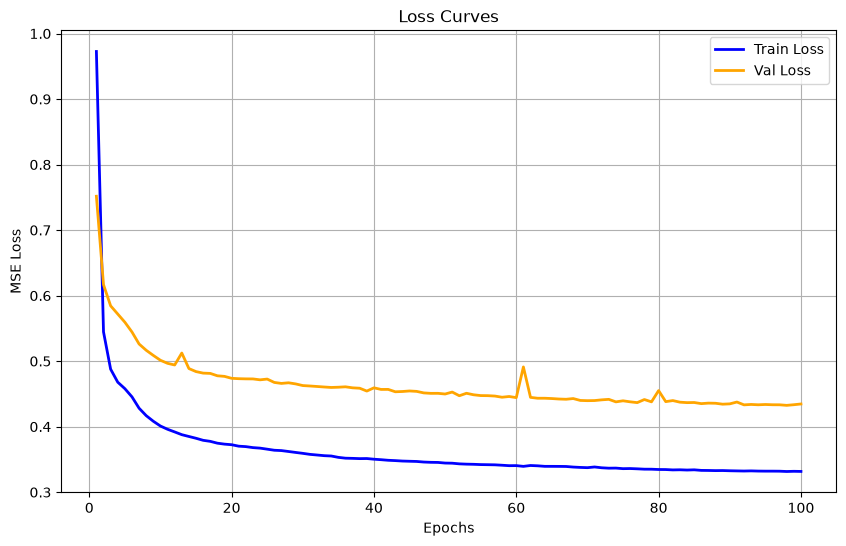

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model = Autoencoder(input_dim=31, latent_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

trained_model, train_losses, val_losses = train_and_validate(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,
    device=device
)

plot_loss_curves(train_losses, val_losses)

In [5]:
pr_auc,reconstruction_error = evaluate_autoencoder(trained_model,
                                                   X_val_tensor,
                                                   y_val,
                                                   device)
pr_auc

0.7202254720167507

In [6]:
reconstruction_error_class_0 = reconstruction_error[y_val == 0]
reconstruction_error_class_1 = reconstruction_error[y_val == 1]

print(pd.DataFrame(reconstruction_error_class_0).describe())
print(pd.DataFrame(reconstruction_error_class_1).describe())

                  0
count  42488.000000
mean       0.336835
std        0.590029
min        0.049974
25%        0.182178
50%        0.252044
75%        0.374812
max       42.396286
                0
count  236.000000
mean    18.040136
std     21.325077
min      0.106200
25%      3.192728
50%      7.622886
75%     22.824722
max     68.012505


In [7]:
output_dir = Path("../models")
output_dir.mkdir(parents=True, exist_ok=True)
torch.save(trained_model.state_dict(), "../models/autoencoder.pth")